In [ ]:
!curl -L "https://drive.google.com/uc?export=download&id=1uCRIl4C1V-a5E11lImbW6q244BN80yKT" -o ../data/sample_2.csv

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction import FeatureHasher

df = pd.read_csv('../data/sample_2.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,2013,Hyundai,Elantra,Limited,Sedan,automatic,5npdh4ae1dh194798,fl,25.0,32997.0,black,gray,hyundai motor finance,13200.0,Tue Jan 06 2015 01:30:00 GMT-0800 (PST)
1,2008,NaN,NaN,NaN,NaN,automatic,1fdns24l58da70495,ga,33.0,85037.0,black,black,akins ford dodge jeep chrysler,17800.0,Thu Jan 15 2015 02:00:00 GMT-0800 (PST)
2,2011,Nissan,Maxima,3.5 SV,Sedan,automatic,1n4aa5ap0bc867447,mo,42.0,65192.0,white,beige,nissan-infiniti lt,15700.0,Wed Feb 18 2015 02:30:00 GMT-0800 (PST)
3,2014,Chevrolet,Impala,LT,Sedan,NaN,2g1125s35e9281298,co,3.0,27296.0,white,gray,gm remarketing,23100.0,Tue Jun 16 2015 04:30:00 GMT-0700 (PDT)
4,2013,Chevrolet,Silverado 1500,LT,Extended Cab,automatic,1gcrcse04dz214378,ga,45.0,20770.0,silver,black,young motors llc,23300.0,Tue Jan 06 2015 01:30:00 GMT-0800 (PST)


In [68]:
print(df.dtypes)
print()
print(df.describe())

year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
sellingprice    float64
saledate         object
dtype: object

               year     condition       odometer   sellingprice
count  50000.000000  48954.000000   49991.000000   49996.000000
mean    2010.022880     30.601973   68516.919906   13606.975698
std        3.988949     13.418754   53602.881833    9780.656646
min     1986.000000      1.000000       1.000000     100.000000
25%     2007.000000     23.000000   28317.000000    6900.000000
50%     2012.000000     34.000000   52384.000000   12200.000000
75%     2013.000000     41.000000   99546.500000   18200.000000
max     2015.000000     49.000000  999999.000000  169000.000000


## Data type

In [69]:
numerical = ['year', 'condition', 'odometer', 'sellingprice']
categorical_ohe = ['body', 'transmission', 'state', 'color', 'interior']
categorical_label = ['make', 'model', 'trim', 'seller']
to_drop = ['vin', 'saledate']

print('Numerical:', numerical)
print('Categorical OHE:', categorical_ohe)
print('Categorical Label:', categorical_label)
print('Drop:', to_drop)

Numerical: ['year', 'condition', 'odometer', 'sellingprice']
Categorical OHE: ['body', 'transmission', 'state', 'color', 'interior']
Categorical Label: ['make', 'model', 'trim', 'seller']
Drop: ['vin', 'saledate']


In [70]:
# Remove rows where transmission has wrong values
df = df[~df['transmission'].isin(['Sedan', 'sedan'])].copy()

# Standardize make capitalization
df['make'] = df['make'].str.capitalize()

# Lowercase body and group rare values
df['body'] = df['body'].str.lower()
body_counts = df['body'].value_counts()
rare = body_counts[body_counts < 50].index
df['body'] = df['body'].replace(rare, 'other')

# Remove top 1% selling prices (outliers)
p99 = np.percentile(df['sellingprice'].dropna(), 99)
df = df[df['sellingprice'] <= p99].copy()

print('Shape after cleaning:', df.shape)

Shape after cleaning: (49504, 15)


## Missing Values

In [71]:
df.isnull().sum()

year               0
make             921
model            922
trim             964
body            1179
transmission    5799
vin                0
state              0
condition       1042
odometer           9
color             63
interior          63
seller             0
sellingprice       0
saledate           0
dtype: int64

## Data Cleaning

In [72]:
# Remove rows where transmission has wrong values
df = df[~df['transmission'].isin(['Sedan', 'sedan'])].copy()

# Standardize make capitalization
df['make'] = df['make'].str.capitalize()

# Lowercase body and group rare values
df['body'] = df['body'].str.lower()
body_counts = df['body'].value_counts()
rare = body_counts[body_counts < 50].index
df['body'] = df['body'].replace(rare, 'other')

# Remove top 1% selling prices
p99 = np.percentile(df['sellingprice'].dropna(), 99)
df = df[df['sellingprice'] <= p99].copy()

# Remove top 1% odometer
p99_odo = np.percentile(df['odometer'].dropna(), 99)
df = df[df['odometer'] <= p99_odo].copy()

print('Shape after cleaning:', df.shape)

Shape after cleaning: (48514, 15)


## Imputation

In [73]:
# Condition - median by make (more accurate than global median)
group_median = df.groupby('make')['condition'].transform('median')
df['condition'] = df['condition'].fillna(group_median)
df['condition'] = df['condition'].fillna(df['condition'].median())

# Odometer - global median
df['odometer'] = df['odometer'].fillna(df['odometer'].median())

# Transmission - mode
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

# Other categoricals - unknown
for col in ['make', 'model', 'trim', 'body', 'color', 'interior']:
    df[col] = df[col].fillna('unknown')

# Drop rows where target is missing
df = df.dropna(subset=['sellingprice'])

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
sellingprice    0
saledate        0
dtype: int64


In [74]:
df = df.drop(columns=['vin', 'saledate'])
print('Shape:', df.shape)
df.head()

Shape: (48514, 13)


,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,sellingprice
0,2013,Hyundai,Elantra,Limited,sedan,automatic,fl,25.0,32997.0,black,gray,hyundai motor finance,13200.0
1,2008,unknown,unknown,unknown,unknown,automatic,ga,33.0,85037.0,black,black,akins ford dodge jeep chrysler,17800.0
2,2011,Nissan,Maxima,3.5 SV,sedan,automatic,mo,42.0,65192.0,white,beige,nissan-infiniti lt,15700.0
3,2014,Chevrolet,Impala,LT,sedan,automatic,co,3.0,27296.0,white,gray,gm remarketing,23100.0
4,2013,Chevrolet,Silverado 1500,LT,extended cab,automatic,ga,45.0,20770.0,silver,black,young motors llc,23300.0


## Feature Encoding

In [75]:
# One-Hot Encoding 
df = pd.get_dummies(df, columns=['body', 'transmission', 'state', 'color', 'interior'])
print('Shape after OHE:', df.shape)
df.head()

Shape after OHE: (48514, 108)


,year,make,model,trim,condition,odometer,seller,sellingprice,body_convertible,body_coupe,...,interior_green,interior_off-white,interior_orange,interior_purple,interior_red,interior_silver,interior_tan,interior_unknown,interior_white,interior_—
0,2013,Hyundai,Elantra,Limited,25.0,32997.0,hyundai motor finance,13200.0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2008,unknown,unknown,unknown,33.0,85037.0,akins ford dodge jeep chrysler,17800.0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2011,Nissan,Maxima,3.5 SV,42.0,65192.0,nissan-infiniti lt,15700.0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2014,Chevrolet,Impala,LT,3.0,27296.0,gm remarketing,23100.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2013,Chevrolet,Silverado 1500,LT,45.0,20770.0,young motors llc,23300.0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [76]:
#Label Encoding 
for col in ['make', 'model', 'trim', 'seller']:
    hasher = FeatureHasher(n_features=16, input_type='string')
    hashed = hasher.transform(df[col].astype(str).apply(lambda x: [x]))
    hashed_df = pd.DataFrame(hashed.toarray(), 
                              columns=[f'{col}_hash_{i}' for i in range(16)],
                              index=df.index)
    df = pd.concat([df.drop(columns=[col]), hashed_df], axis=1)

print('Shape after Hash Encoding:', df.shape)
df.head()

Shape after Hash Encoding: (48514, 168)


,year,condition,odometer,sellingprice,body_convertible,body_coupe,body_crew cab,body_crewmax cab,body_double cab,body_e-series van,...,seller_hash_6,seller_hash_7,seller_hash_8,seller_hash_9,seller_hash_10,seller_hash_11,seller_hash_12,seller_hash_13,seller_hash_14,seller_hash_15
0,2013,25.0,32997.0,13200.0,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2008,33.0,85037.0,17800.0,False,False,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011,42.0,65192.0,15700.0,False,False,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014,3.0,27296.0,23100.0,False,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013,45.0,20770.0,23300.0,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Feature Scaling

In [77]:
# Save original values for comparison
df_before = df[['year', 'condition', 'odometer']].copy()

In [78]:
#Feature Scaling
scaler = StandardScaler()
df[['year', 'condition', 'odometer']] = scaler.fit_transform(df[['year', 'condition', 'odometer']])

df.head()

,year,condition,odometer,sellingprice,body_convertible,body_coupe,body_crew cab,body_crewmax cab,body_double cab,body_e-series van,...,seller_hash_6,seller_hash_7,seller_hash_8,seller_hash_9,seller_hash_10,seller_hash_11,seller_hash_12,seller_hash_13,seller_hash_14,seller_hash_15
0,0.755538,-0.428747,-0.702670,13200.0,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.520757,0.177594,0.359983,17800.0,False,False,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.245020,0.859728,-0.045250,15700.0,False,False,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.010796,-2.096186,-0.819084,23100.0,False,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.755538,1.087106,-0.952345,23300.0,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


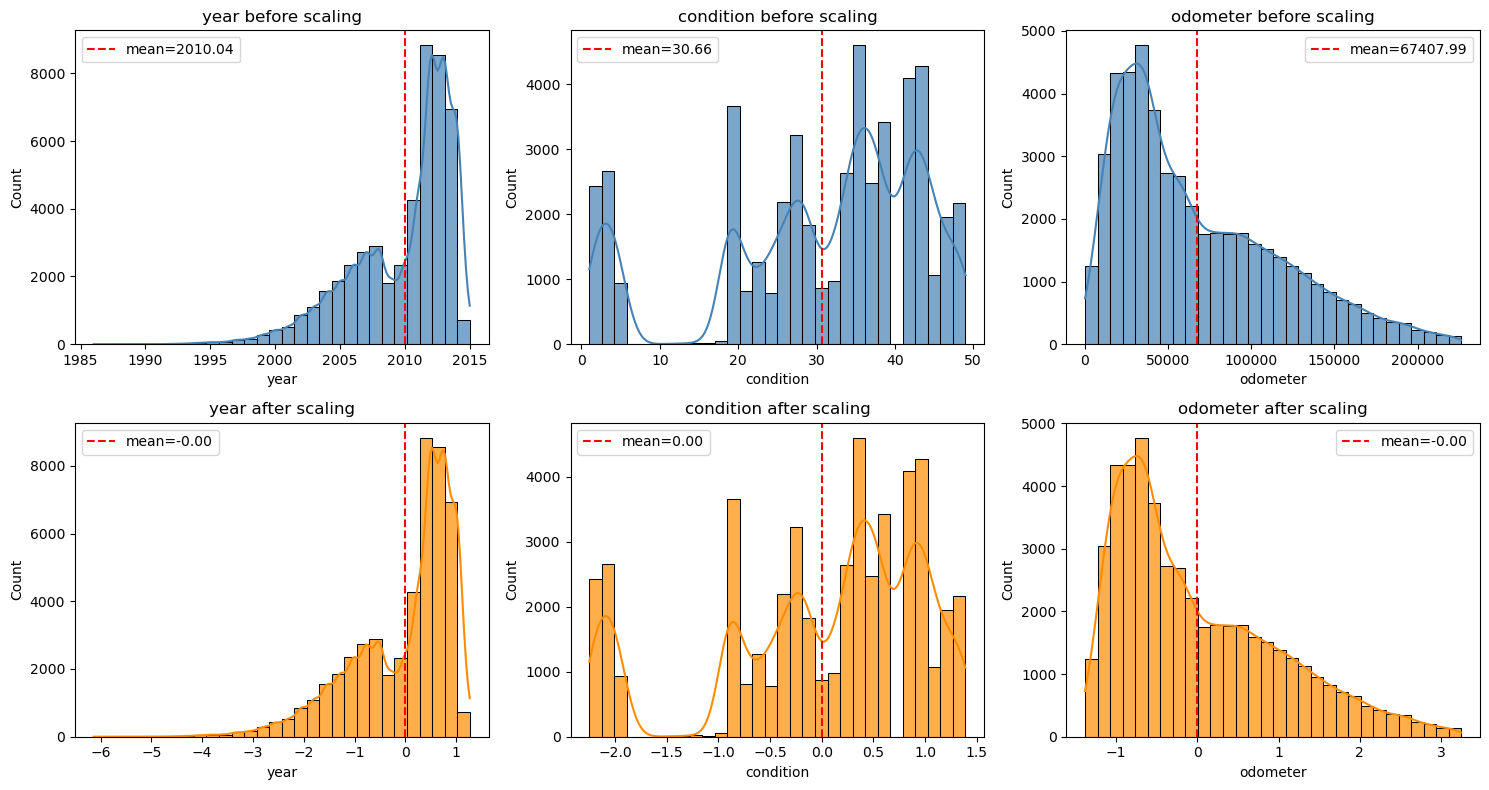

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(['year', 'condition', 'odometer']):
    sns.histplot(df_before[col], ax=axes[0, i], kde=True, bins=30, alpha=0.7, color='steelblue')
    axes[0, i].set_title(f'{col} before scaling')
    axes[0, i].axvline(df_before[col].mean(), color='red', linestyle='--',
                       label=f'mean={df_before[col].mean():.2f}')
    axes[0, i].legend()

    sns.histplot(df[col], ax=axes[1, i], kde=True, bins=30, alpha=0.7, color='darkorange')
    axes[1, i].set_title(f'{col} after scaling')
    axes[1, i].axvline(df[col].mean(), color='red', linestyle='--',
                       label=f'mean={df[col].mean():.2f}')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

In [80]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/data_prepared.csv', index=False)
print('Saved! Shape:', df.shape)

Saved! Shape: (48514, 168)


## Preprocessing Summary

- **Removed** bad `transmission` values ('Sedan')
- **Standardized** `make` capitalization
- **Grouped** rare `body` types into 'other'
- **Removed outliers** — top 1% of `sellingprice` and `odometer`
- **Imputed** `condition` with median by make, `odometer` with global median
- **Filled** categorical columns with 'unknown'
- **Dropped** `vin` and `saledate` — not useful for prediction
- **One-Hot Encoded** `body`, `transmission`, `state`, `color`, `interior`
- **Label Encoded** `make`, `model`, `trim`, `seller`
- **Scaled** `year`, `condition`, `odometer` with StandardScaler
- **Saved** processed data to `data/processed/data_prepared.csv`